**Our Problem Statement is to analyze the dataset of properties in Islamabad and then building a model to predict its price using location, Area(Sq.ft), bedrooms, baths...**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('property_with_Feature_Engineering.csv')

In [3]:
df.head()

,property_id,location_id,page_url,property_type,price,price_bin,location,city,province_name,locality,...,area_marla,area_sqft,purpose,bedrooms,date_added,year,month,day,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Very High,Model Town,Lahore,Punjab,"Model Town, Lahore, Punjab",...,120.0,32670.12,For Sale,0,07-17-2019,2019,7,17,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Very High,Multan Road,Lahore,Punjab,"Multan Road, Lahore, Punjab",...,20.0,5445.02,For Sale,5,10-06-2018,2018,10,6,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Low,Eden,Lahore,Punjab,"Eden, Lahore, Punjab",...,9.0,2450.26,For Sale,3,07-03-2019,2019,7,3,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Very High,Gulberg,Lahore,Punjab,"Gulberg, Lahore, Punjab",...,20.0,5445.02,For Sale,8,04-04-2019,2019,4,4,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,High,Allama Iqbal Town,Lahore,Punjab,"Allama Iqbal Town, Lahore, Punjab",...,11.0,2994.76,For Sale,6,04-04-2019,2019,4,4,NaN,NaN


In [4]:
df = df[df['city'] == 'Islamabad']
df.head(2)

,property_id,location_id,page_url,property_type,price,price_bin,location,city,province_name,locality,...,area_marla,area_sqft,purpose,bedrooms,date_added,year,month,day,agency,agent
396,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,High,G-10,Islamabad,Islamabad Capital,"G-10, Islamabad, Islamabad Capital",...,4.0,1089.00,For Sale,2,02-04-2019,2019,2,4,NaN,NaN
397,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,Medium,E-11,Islamabad,Islamabad Capital,"E-11, Islamabad, Islamabad Capital",...,5.6,1524.61,For Sale,3,05-04-2019,2019,5,4,NaN,NaN


In [5]:
df.shape

(40195, 24)

## EDA

There are so much unnecessary columns which will not be used in model and they can impact models performance so we will be dropping those columns

In [6]:
# dropping unnecessary columns
col_names = ["location_id","page_url","province_name","locality","area_marla","year","month","day","agency","agent","latitude","longitude","property_id","property_type","price_bin","purpose","date_added","city","area"]
df = df.drop(col_names, axis=1)

In [7]:
df = df.reset_index()
df = df.drop("index",axis=1)
df.head()

,price,location,baths,area_sqft,bedrooms
0,10000000,G-10,2,1089.00,2
1,6900000,E-11,3,1524.61,3
2,16500000,G-15,6,2178.01,5
3,70000000,F-10,6,8167.53,6
4,43500000,Bani Gala,4,10890.04,4


In [8]:
df.sample(5)

,price,location,baths,area_sqft,bedrooms
27710,525000,F-6,0,10890.04,0
39593,29000,Lehtarar Road,2,1089.00,1
11382,43000,DHA Defence,0,5445.02,0
21796,45000,G-6,2,1905.76,2
10687,20000000,DHA Defence,0,2994.76,0


In [9]:
df.isnull().sum()

price        0
location     0
baths        0
area_sqft    0
bedrooms     0
dtype: int64

In [10]:
df.shape

(40195, 5)

In [11]:
df['bedrooms'].unique()

array([ 2,  3,  5,  6,  4,  8,  7,  0,  1, 10,  9, 11, 12, 16, 18, 15, 21,
       14])

## Data Cleaning

As You can see in the above cell that there are some properties which have bedrooms even greater than 10...This could be possible that some of them could be typo error while others can be having other errors in them as well like very less baths or no baths...Lets inspect the properties that are having bedrooms more than 12

In [12]:
df[df['bedrooms']>12]

,price,location,baths,area_sqft,bedrooms
3735,140000000,F-11,0,10890.04,16
6419,550000,F-7,10,13068.05,18
19183,115000000,E-11,0,6534.02,16
27874,90000000,G-14,0,7078.53,15
28784,300000,G-14,0,6534.02,21
31229,90000000,G-13,0,7078.53,15
33849,650000,F-8,0,21780.08,14
33854,650000,F-8,14,21780.08,14
37650,90000000,G-14,0,7078.53,15


Notice how some of them are having no baths and some are having very less number of baths as compared to their bedrooms...

In [13]:
df['baths'].unique()

array([ 2,  3,  6,  4,  8,  7,  5,  0,  1, 10,  9, 11, 12, 13, 14])

In the above cell, You will see that there are up to 14 numbers of baths which is quite uncommon and may be a typo error or other kind of error.

In [14]:
df = df.drop(df[(df['baths']==0) & (df['bedrooms'] > 3)].index)
df

,price,location,baths,area_sqft,bedrooms
0,10000000,G-10,2,1089.00,2
1,6900000,E-11,3,1524.61,3
2,16500000,G-15,6,2178.01,5
3,70000000,F-10,6,8167.53,6
4,43500000,Bani Gala,4,10890.04,4
...,...,...,...,...,...
40190,70000,I-8,0,3375.91,3
40191,40000,I-8,0,3375.91,2
40192,160000,G-10,6,5445.02,6
40193,25000,DHA Defence,2,735.08,2


In the above cell we have dropped those indexes that are having no baths and having bedrooms greater than 3 cause they can probably be a typo error.

In [15]:
df.drop(df[(df['bedrooms']==0) | (df['baths']==0)].index, inplace=True)

We have also dropped those rows where have 0 bedrooms and 0 baths.

In [16]:
df[df["baths"] > df["bedrooms"]].head(10)

,price,location,baths,area_sqft,bedrooms
2,16500000,G-15,6,2178.01,5
16,13500000,DHA Defence,5,2722.51,3
23,55000000,G-11,7,3811.51,6
35,4500000,Ghauri Town,3,1361.25,2
43,14000000,F-17,6,1905.76,4
45,32500000,Korang Town,9,3267.01,7
47,30000000,Bahria Town,7,2722.51,6
49,21000000,Bahria Town,6,2722.51,5
55,14500000,Ghauri Town,5,1905.76,4
57,850000000,F-6,10,26136.10,9


There are some homes that are having more number of baths as compared to its bedrooms which is quite uncommon...

## Outliers Detections and Removals

In [17]:
df['price_per_sqft'] = df['price'] / df['area_sqft']
df.head()

,price,location,baths,area_sqft,bedrooms,price_per_sqft
0,10000000,G-10,2,1089.00,2,9182.736455
1,6900000,E-11,3,1524.61,3,4525.747568
2,16500000,G-15,6,2178.01,5,7575.722793
3,70000000,F-10,6,8167.53,6,8570.522545
4,43500000,Bani Gala,4,10890.04,4,3994.475686


We have added a new column for feature engineering so that outliers can detected and removed easily.


In [18]:
df['location'].nunique()

207

In [19]:
df['location'] = df['location'].apply(lambda x: x.strip())
location_status = df.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_status.head(30)

location
DHA Defence                       3051
E-11                              2495
G-13                              2016
G-11                              1676
I-8                               1657
F-11                              1643
Bahria Town                       1304
G-15                              1147
F-10                              1108
F-8                               1074
F-7                               1058
I-10                               925
Ghauri Town                        811
Soan Garden                        647
F-6                                646
Bani Gala                          619
PWD Housing Scheme                 545
G-10                               493
B-17                               409
G-9                                406
CBR Town                           347
Gulberg                            317
FECHS                              284
H-13                               283
Pakistan Town                      277
D-12            

In [20]:
len(location_status[location_status <= 12])

109

Notice that there are 109 locations that are having properties less than 12 so we can categorize them as others which will help us in dimensionality reduction in our machine learning model.

In [21]:
locations_less_than_12 = location_status[location_status <= 12]
df['location'] = df['location'].apply(lambda x:'others' if x in locations_less_than_12 else x)

In [22]:
df['location'].nunique()

99

Firstly there were 207 unique locations and now we are having only 99 unique locations after dimensionality reduction

In [23]:
df[df['area_sqft'] / df['bedrooms'] < 400]

,price,location,baths,area_sqft,bedrooms,price_per_sqft
27,4500000,Garden Town,4,1279.58,4,3.516779e+03
28,6800000,others,4,1089.00,4,6.244261e+03
36,12500000,I-16,5,2178.01,6,5.739184e+03
41,46500000,G-13,9,2967.54,9,1.566954e+04
54,14000000,G-13,5,1089.00,5,1.285583e+04
...,...,...,...,...,...,...
40155,33000,D-17,3,163.35,3,2.020202e+02
40165,36000,I-10,2,0.00,2,inf
40166,90000,D-17,9,163.35,9,5.509642e+02
40193,25000,DHA Defence,2,735.08,2,3.400990e+01


In the above cell we assume that on  minimum a bedroom must be more than 400 sq.ft so those that were not following that rule in our data we will be removing them as they will be considered as outliers...

In [24]:
df.drop(df[df['area_sqft'] / df['bedrooms'] < 400].index, inplace = True)

In [25]:
df['price_per_sqft'].describe()

count     26390.000000
mean       3311.621123
std        5379.932614
min           0.000413
25%          18.365395
50%          36.730946
75%        5903.172234
max      167793.638868
Name: price_per_sqft, dtype: float64

Standard Deviation is too high in the above cell, We will be reducing it.


In [26]:
# removing price_per_sqft outliers 
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key,subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        std = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf['price_per_sqft'] > (m-std)) & (subdf['price_per_sqft'] <= (m+std))]
        df_out = pd.concat([df_out,reduced_df], ignore_index=True)
    return df_out

In [27]:
df = remove_pps_outliers(df)
df.shape

(20657, 6)

In [28]:
import matplotlib.pyplot as plt
import matplotlib
def plot_scatter_chart(df, location):
    bedroom_2 = df[(df['location'] == location) & (df['bedrooms'] == 2)]
    bedroom_3 = df[(df['location'] == location) & (df['bedrooms'] == 3)]
    matplotlib.rcParams["figure.figsize"] = (10,5)
    plt.scatter(bedroom_2['area_sqft'], bedroom_2['price']/100000, color='blue', label="2 Bedroom", s=50)
    plt.scatter(bedroom_3['area_sqft'], bedroom_3['price']/100000, marker='+', color="green", label="3 Bedroom", s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price")
    plt.title(location)
    plt.legend()

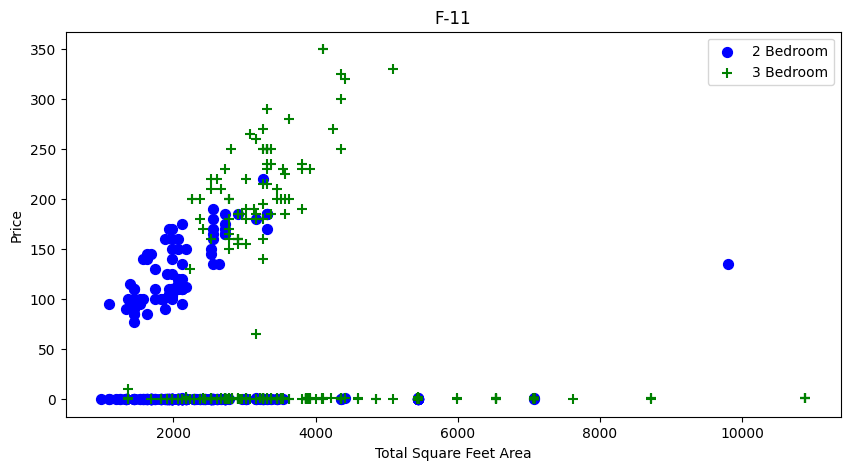

In [29]:
plot_scatter_chart(df, "F-11")

Notice in the above graph that there are some properties having 3 bedrooms still in less price than 2 bedrooms properties in a specfied location. Now they can also be considered as outliers and we should also remove them so that they cannot affect our model performance

In [30]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby("location"):
        bhk_stats = {}
        for bedroom, bedroom_df in location_df.groupby("bedrooms"):
            bhk_stats[bedroom] = {
                'mean' : np.mean(bedroom_df["price_per_sqft"]),
                'std' : np.std(bedroom_df["price_per_sqft"]),
                'count': bedroom_df.shape[0]
            }
        for bedroom, bedroom_df in location_df.groupby("bedrooms"):
            stats = bhk_stats.get(bedroom - 1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bedroom_df[bedroom_df['price_per_sqft'] < (stats['mean'])].index.values)
    return df.drop(exclude_indices, axis="index") 

In [31]:
df = remove_bhk_outliers(df)
df.shape

(8047, 6)

In [32]:
df.groupby('location')['location'].agg('count').sort_values(ascending=False).head(40)

location
DHA Defence                       804
Bahria Town                       506
I-10                              488
E-11                              477
F-7                               373
F-8                               344
G-11                              340
F-11                              329
F-6                               274
G-15                              231
F-10                              229
Ghauri Town                       214
Bani Gala                         212
Gulberg                           169
I-8                               163
CBR Town                          150
Soan Garden                       148
others                            138
Pakistan Town                     131
B-17                              119
G-13                              119
Lehtarar Road                     109
FECHS                             104
F-17                               95
E-7                                91
Bhara kahu                         90
PWD

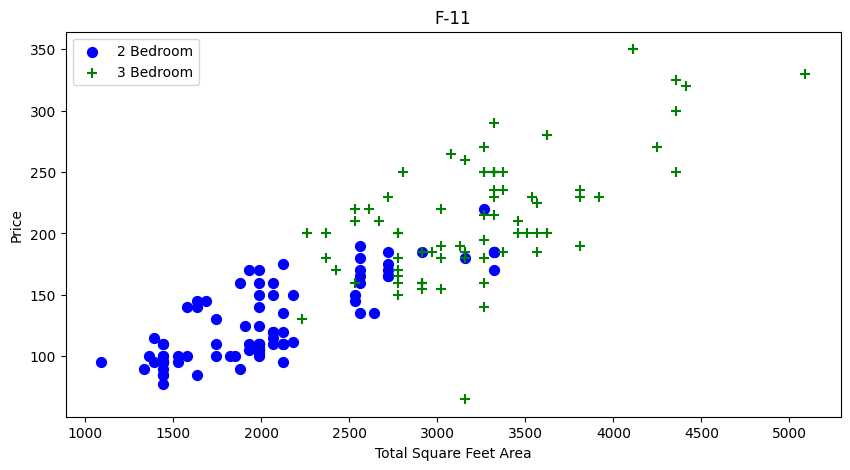

In [33]:
plot_scatter_chart(df, "F-11")

In [34]:
df[df['baths'] > df['bedrooms']]

,price,location,baths,area_sqft,bedrooms,price_per_sqft
16,35000,7th Avenue,3,1905.76,2,18.365377
17,35000,7th Avenue,3,1905.76,2,18.365377
19,400000,7th Avenue,6,5445.02,4,73.461622
21,300000,7th Avenue,7,7078.53,6,42.381681
24,700000,7th Avenue,7,21780.08,6,32.139460
...,...,...,...,...,...,...
20611,15500000,others,6,2722.51,5,5693.275690
20639,5300000,others,3,1361.25,2,3893.480257
20641,85000000,others,9,27225.10,7,3122.118927
20644,85000000,others,9,27225.10,7,3122.118927


In [35]:
df[df['baths'] > (df['bedrooms'] + 2)]

,price,location,baths,area_sqft,bedrooms,price_per_sqft
116,13000000,B-17,7,2178.01,4,5968.751291
286,30000000,Bahria Town,7,2722.51,4,11019.243272
535,49500000,Bahria Town,10,5445.02,7,9090.875699
999,10600000,Bahria Town,10,1524.61,3,6952.597714
1592,75000000,Bani Gala,7,27225.10,4,2754.810818
1710,7500000,Bhara kahu,8,1905.76,3,3935.437831
2040,18000,Chatha Bakhtawar,5,1361.25,2,13.223140
2049,25000,Chatha Bakhtawar,6,1361.25,2,18.365473
2163,300000,D-12,13,6534.02,10,45.913542
2210,11700000,D-17,8,2531.93,4,4620.980833


In [36]:
df = df.drop(df[df['baths'] > (df['bedrooms'] + 2)].index)
df.shape

(8014, 6)

In [37]:
df1 = df.drop("price_per_sqft", axis=1)

In [38]:
dummies = pd.get_dummies(df1['location'])
dummies.head(3)

,7th Avenue,9th Avenue,Ali Pur,Alipur Farash,Arsalan Town,B-17,Bahria Town,Bani Gala,Bhara kahu,Blue Area,...,Simly Dam Road,Soan Garden,Swan Garden,Taramrri,Tarlai,Tarnol,Thanda Pani,The Springs,Zaraj Housing Scheme,others
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


We have removed the Price per sqft feature because it does not required anymore and also we have added dummies of locations.

In [41]:
df1 = pd.concat([df1, dummies.drop('others', axis=1)], axis="columns")
df1 = df1.drop("location", axis=1)
df1.head()
df1.shape

KeyError: "['location'] not found in axis"

In [42]:
df1.head()

,price,baths,area_sqft,bedrooms,7th Avenue,9th Avenue,Ali Pur,Alipur Farash,Arsalan Town,B-17,...,Shehzad Town,Simly Dam Road,Soan Garden,Swan Garden,Taramrri,Tarlai,Tarnol,Thanda Pani,The Springs,Zaraj Housing Scheme
0,90000,2,1742.41,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1000000,8,10890.04,8,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,17000,1,1361.25,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,20000,2,1361.25,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,65000,2,2722.51,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Model Evaluation

In [43]:
x = df1.drop('price', axis=1) 
x.head()

,baths,area_sqft,bedrooms,7th Avenue,9th Avenue,Ali Pur,Alipur Farash,Arsalan Town,B-17,Bahria Town,...,Shehzad Town,Simly Dam Road,Soan Garden,Swan Garden,Taramrri,Tarlai,Tarnol,Thanda Pani,The Springs,Zaraj Housing Scheme
0,2,1742.41,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,8,10890.04,8,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,1361.25,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,1361.25,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2,2722.51,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [44]:
y = df1['price'] 
y.head()

0      90000
1    1000000
2      17000
3      20000
4      65000
Name: price, dtype: int64

In [45]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

0.18477318486937977